# Risk assessment for windstorms — Kazakhstan

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[STORMS](https://github.com/CLIMAAX/STORMS) GitHub repository for Kazakhstan.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| LUISA land cover (EU-only, 50m, EPSG:3035) | ESA WorldCover 2021 v2.0 (global, 10m→100m, EPSG:4326) | LUISA covers only Europe |
| LUISA class codes (1111, 1121 …) | ESA WorldCover class codes (10, 40, 50 …) | Class system tied to dataset |
| Building-type ratio table (per LUISA class) | Single representative curve for built-up class 50 | No published building-type ratio table for Kazakhstan; Soviet-era urban stock dominated by concrete panel construction |
| Max damage in €/m² (EU GDP-adjusted Excel) | Max damage in USD/m² from Huizinga 2017 (Central Asia region) | Huizinga provides global values; EU values not valid outside Europe |
| DamageScanner library | Direct numpy raster calculation | DamageScanner requires osgeo/GDAL (unavailable in crabook-kz) |
| EPSG:3035 projected CRS | EPSG:4326 geographic CRS | EPSG:3035 is Europe-only |
| contextily attribution_size= | attribution=False | Parameter not supported in this env |

**Feuerstein curves** are retained (Decision 3b): no published wind vulnerability
curves exist for Central Asian / post-Soviet building stock. The curves are used
as the best available approximation.
Adjust `BUILT_UP_CURVE` in the configuration cell if needed.

**References:**
- Feuerstein et al. (2011). doi:10.1016/j.atmosres.2010.12.026
- Huizinga et al. (2017). JRC105688. doi:10.2760/16510
- Koks & Haer (2020). doi:10.1038/s41598-020-63580-w

## Load libraries

In [ ]:
import math
import logging
from pathlib import Path

import pooch
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
import rasterio
from rasterio.windows import from_bounds as rio_from_bounds
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import contextily as ctx

logging.getLogger('pooch').setLevel(logging.WARNING)

## Configuration

In [ ]:
storm_name = "buran_nov2023"

oblast_filter = "Pavlodar Region"  

BUILT_UP_CURVE = 'weakest outbuilding'

MAXDAM_BUILT_UP_USD = 452.0

## Paths

In [ ]:
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)
OBLAST_FIELD = 'oblast_en'

work_dir = Path('.')

hazard_data_dir  = work_dir / 'STORM_event_raster' / f'data_{storm_name}'

workflow_folder  = work_dir / 'STORM_risk'
data_general_dir = workflow_folder / 'general_data'
data_dir         = workflow_folder / 'data'
results_dir      = workflow_folder / 'results'
plot_dir         = workflow_folder / 'plots'

for d in [data_general_dir, data_dir, results_dir, plot_dir]:
    d.mkdir(parents=True, exist_ok=True)

## Load Kazakhstan boundary

In [30]:
kaz = gpd.read_file(SHAPEFILE_PATH)

if oblast_filter is not None:
    region_gdf  = kaz[kaz[OBLAST_FIELD] == oblast_filter].dissolve()
    if region_gdf.empty:
        raise ValueError(
            f"No rows found for {OBLAST_FIELD} == '{oblast_filter}'. "
            f"Available: {kaz[OBLAST_FIELD].unique().tolist()}"
        )
    analysis_label = oblast_filter
    region_name    = re.sub(r'[^a-zA-Z0-9]', '', oblast_filter)
else:
    region_gdf     = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)
    analysis_label = 'Kazakhstan'
    region_name    = 'Kazakhstan'

coords = gpd.GeoSeries.get_coordinates(region_gdf).to_numpy()
bbox = [
    float(coords[:, 0].min()),
    float(coords[:, 1].min()),
    float(coords[:, 0].max()),
    float(coords[:, 1].max()),
]
print(f'Region : {analysis_label}')
print(f'Bbox   : {bbox}')

Region : Pavlodar Region
Bbox   : [73.40578069999998, 50.01343609999998, 79.34714020000007, 54.45776790000002]


## 1 — Hazard: load wind footprint from hazard notebook

Footprint shape     : (65, 169)
Resolution (ERA5)   : (0.25, -0.25)
Max gust (m/s)      : 32.4


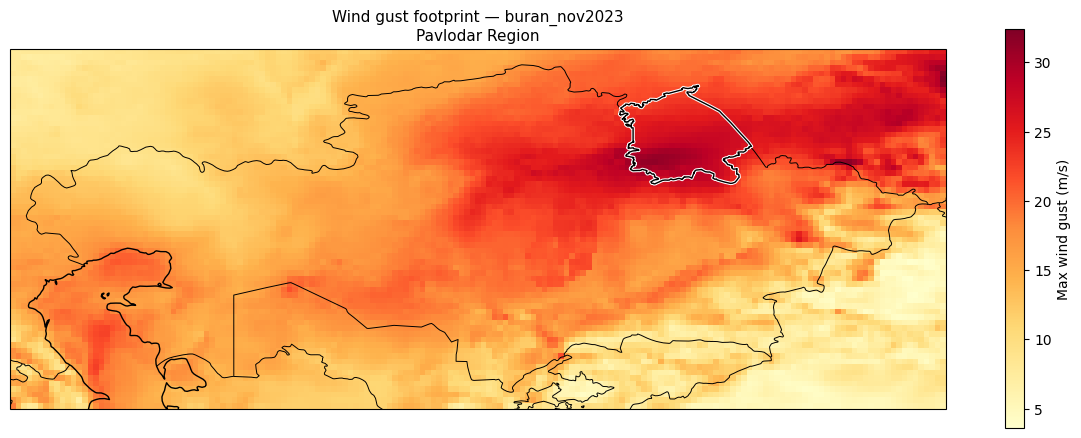

In [ ]:
footprint_path = hazard_data_dir / f'{storm_name}.nc'

if not footprint_path.exists():
    raise FileNotFoundError(
        f"Footprint file not found: {footprint_path}\n"
        "Run Hazard_assessment_STORMS_KZ.py first to produce the footprint."
    )

windstorm_region = rxr.open_rasterio(str(footprint_path), masked=True).squeeze()
windstorm_region.rio.write_crs('EPSG:4326', inplace=True)
windstorm_region = windstorm_region.where(windstorm_region > 0)

print(f'Footprint shape     : {windstorm_region.shape}')
print(f'Resolution (ERA5)   : {windstorm_region.rio.resolution()}')
print(f'Max gust (m/s)      : {float(windstorm_region.max()):.1f}')

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
windstorm_region.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='YlOrRd', cbar_kwargs={'label': 'Max wind gust (m/s)', 'shrink': 0.7}
)
for geom in region_gdf.geometry:
    if geom.geom_type == 'Polygon':
        parts = [geom]
    else:
        parts = list(geom.geoms)
    for part in parts:
        xs, ys = part.exterior.xy
        ax.plot(xs, ys, transform=ccrs.PlateCarree(), color='black', linewidth=1.0,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
ax.coastlines(resolution='50m')
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.set_title(f'Wind gust footprint — {storm_name}\n{analysis_label}', fontsize=11)
plt.tight_layout()
fig.savefig(plot_dir / f'Footprint_{storm_name}_{region_name}.png', dpi=150)
plt.show()

## 2 — Exposure: ESA WorldCover 2021

**Substitution:** LUISA (EU-only, 50m, EPSG:3035) → ESA WorldCover 2021 v2.0
(global, 10m resampled to ~100m). Tiles are 3°×3°, hosted on a public AWS S3
bucket — no registration required.
Same download and resampling pattern as the flood risk workflow.

In [32]:
ESA_WC_BASE = 'https://esa-worldcover.s3.amazonaws.com/v200/2021/map'

def esa_wc_tiles_for_bbox(bbox):
    lon_min, lat_min, lon_max, lat_max = bbox
    tiles = []
    for lat in range(int(math.floor(lat_min / 3)) * 3, int(math.ceil(lat_max / 3)) * 3, 3):
        for lon in range(int(math.floor(lon_min / 3)) * 3, int(math.ceil(lon_max / 3)) * 3, 3):
            ns = f'N{lat:02d}' if lat >= 0 else f'S{abs(lat):02d}'
            ew = f'E{lon:03d}' if lon >= 0 else f'W{abs(lon):03d}'
            tiles.append(f'{ns}{ew}')
    return tiles

def download_esa_wc_tile(tile_name, dest_folder):
    fname    = f'ESA_WorldCover_10m_2021_v200_{tile_name}_Map.tif'
    out_path = dest_folder / fname
    if out_path.exists():
        print(f'  Cached: {fname}')
    else:
        pooch.retrieve(
            url=f'{ESA_WC_BASE}/{fname}',
            known_hash=None, path=dest_folder, fname=fname
        )
        print(f'  Downloaded: {fname}')
    return out_path

esa_wc_dir = data_general_dir / 'esa_wc_tiles'
esa_wc_dir.mkdir(exist_ok=True)

tile_names = esa_wc_tiles_for_bbox(bbox)
print(f'Tiles needed: {tile_names}')
tile_paths = [download_esa_wc_tile(t, esa_wc_dir) for t in tile_names]

Tiles needed: ['N48E072', 'N48E075', 'N48E078', 'N51E072', 'N51E075', 'N51E078', 'N54E072', 'N54E075', 'N54E078']


SHA256 hash of downloaded file: 180b312363559ca28bcf845069a8be379b1c124ee4368e0fdc4f1a5d1a5a6210
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  Downloaded: ESA_WorldCover_10m_2021_v200_N48E072_Map.tif


SHA256 hash of downloaded file: 826d79b5d9eeb36b4a1d10bfcf58258618a5e308c224d66afa40147b60d111e7
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  Downloaded: ESA_WorldCover_10m_2021_v200_N48E075_Map.tif


...

  Downloaded: ESA_WorldCover_10m_2021_v200_N54E072_Map.tif


SHA256 hash of downloaded file: edf6ead393948c1379e491f0a829a9736390d736b5c320d57f513675dcb08ed5
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  Downloaded: ESA_WorldCover_10m_2021_v200_N54E075_Map.tif


SHA256 hash of downloaded file: 53cbee79da60088fba582a70279fd6ad8a0e8f4e243d580208c3ab8633c7662e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  Downloaded: ESA_WorldCover_10m_2021_v200_N54E078_Map.tif


In [ ]:
TARGET_RES_DEG = 100 / 111320

clipped_paths = []
for p in tile_paths:
    out_path = esa_wc_dir / p.name.replace('.tif', '_clipped100m.tif')
    if out_path.exists():
        print(f'  Cached: {out_path.name}')
    else:
        with rasterio.open(p) as src:
            tb = src.bounds
            x0 = max(tb.left,   bbox[0])
            y0 = max(tb.bottom, bbox[1])
            x1 = min(tb.right,  bbox[2])
            y1 = min(tb.top,    bbox[3])
            if x0 >= x1 or y0 >= y1:
                print(f'  Skipped (no overlap): {p.name}')
                continue
            # Output size based on intersection extent only
            out_h = max(1, int((y1 - y0) / TARGET_RES_DEG))
            out_w = max(1, int((x1 - x0) / TARGET_RES_DEG))
            win  = rio_from_bounds(x0, y0, x1, y1, src.transform)
            data = src.read(1, window=win, out_shape=(out_h, out_w),
                            resampling=Resampling.nearest)
            out_tf = rasterio.transform.from_bounds(x0, y0, x1, y1, out_w, out_h)
            with rasterio.open(out_path, 'w', driver='GTiff',
                               height=out_h, width=out_w, count=1,
                               dtype=data.dtype, crs=src.crs,
                               transform=out_tf) as dst:
                dst.write(data, 1)
        print(f'  Saved 100m: {out_path.name}  shape: {data.shape}')
    clipped_paths.append(out_path)

esa_wc_arrays = [rxr.open_rasterio(p, masked=True) for p in clipped_paths]
esa_wc_local  = (
    merge_arrays(esa_wc_arrays).squeeze()
    if len(esa_wc_arrays) > 1
    else esa_wc_arrays[0].squeeze()
)
esa_wc_local.rio.write_crs('EPSG:4326', inplace=True)
print(f'ESA WC shape: {esa_wc_local.shape}  res: {esa_wc_local.rio.resolution()}')

landcover_path = data_dir / f'land_cover_ESA_WC_{region_name}.tif'
esa_wc_local.rio.to_raster(landcover_path)
print(f'Saved: {landcover_path.name}')

  Cached: ESA_WorldCover_10m_2021_v200_N48E072_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E075_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N48E078_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E072_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E075_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E078_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E072_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E075_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E078_Map_clipped100m.tif
ESA WC shape: (8283, 10017)  res: (0.0008984725965858032, -0.0008984725965858032)


c:\Users\dauzo\miniconda3\envs\crabook-kz\Lib\site-packages\IPython\core\interactiveshell.py:3178: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  result = runner(coro)


Saved: land_cover_ESA_WC_PavlodarRegion.tif


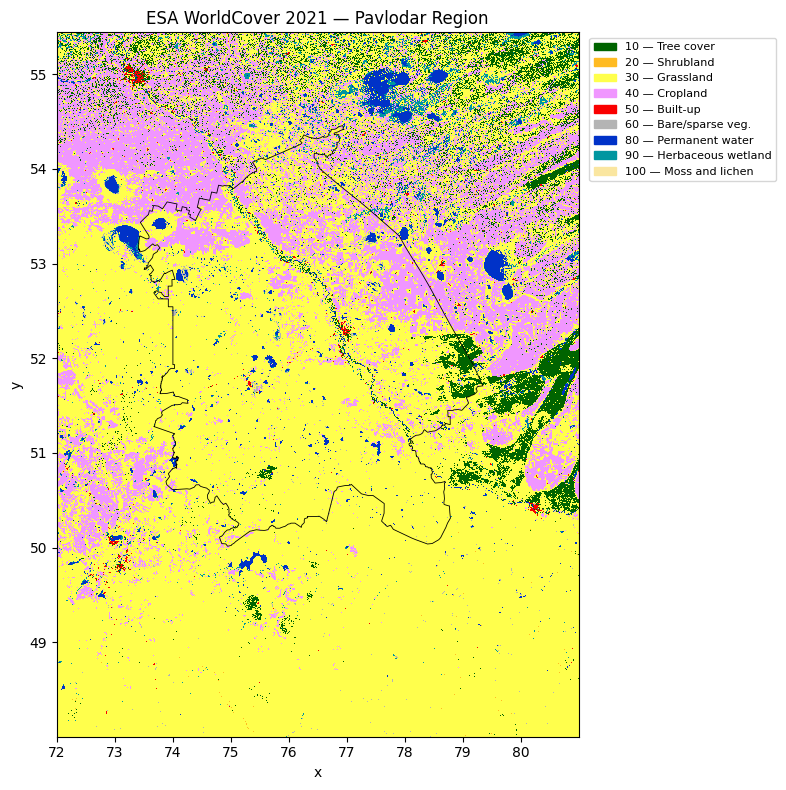

In [34]:
ESA_WC_LABELS = {
    10:  ('Tree cover',         '#006400'),
    20:  ('Shrubland',          '#ffbb22'),
    30:  ('Grassland',          '#ffff4c'),
    40:  ('Cropland',           '#f096ff'),
    50:  ('Built-up',           '#fa0000'),
    60:  ('Bare/sparse veg.',   '#b4b4b4'),
    70:  ('Snow and ice',       '#f0f0f0'),
    80:  ('Permanent water',    '#0032c8'),
    90:  ('Herbaceous wetland', '#0096a0'),
    95:  ('Mangroves',          '#00cf75'),
    100: ('Moss and lichen',    '#fae6a0'),
}

lc_vals         = esa_wc_local.values
present_classes = sorted(
    set(int(v) for v in lc_vals[~np.isnan(lc_vals)]) & ESA_WC_LABELS.keys()
)
cmap_lc = mcolors.ListedColormap([ESA_WC_LABELS[c][1] for c in present_classes])
bounds  = present_classes + [present_classes[-1] + 1]
norm_lc = mcolors.BoundaryNorm(bounds, cmap_lc.N)

fig, ax = plt.subplots(figsize=(10, 8))
esa_wc_local.isel(x=slice(None, None, 3), y=slice(None, None, 3)).plot(
    ax=ax, cmap=cmap_lc, norm=norm_lc, add_colorbar=False
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)
ctx.add_basemap(ax=ax, crs='EPSG:4326',
                source=ctx.providers.CartoDB.Positron, attribution=False)
legend_patches = [
    mpatches.Patch(color=ESA_WC_LABELS[c][1],
                   label=f'{c} — {ESA_WC_LABELS[c][0]}')
    for c in present_classes
]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8)
ax.set_title(f'ESA WorldCover 2021 — {analysis_label}')
plt.tight_layout()
fig.savefig(plot_dir / f'LandCover_{region_name}.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Vulnerability: Feuerstein wind damage curves

Six curves from Feuerstein et al. (2011), downloaded from the CLIMAAX STORMS
repository. Wind speed (m/s) vs. damage fraction [0–1].

**Kazakhstan note (Decision 3b):** These curves were calibrated against Central
European damage data. No equivalent curves exist for Central Asian / post-Soviet
building stock. `BUILT_UP_CURVE` (set in configuration) selects which curve to
apply to all built-up pixels (class 50). Default is 'weakest outbuilding' for this event — selected because buran_nov2023
produced a maximum ERA5 gust of ~31 m/s over Pavlodar Region, which is below
the 'concrete building' onset threshold of 60 m/s. 'weakest outbuilding' activates
at 27 m/s and is appropriate for lightweight rural and peri-urban structures most
exposed to buran wind damage on flat steppe.

**Only class 50 (built-up) receives wind damage in this workflow.** Wind damage
to trees, crops, and other land-cover classes is not modelled here (no
published vulnerability curves for those asset types in Central Asia).

In [ ]:
curves_path = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\notebooks\workflows\STORMS\01_windstorm\CURVES_feuerstein_koks.csv'
)
if not curves_path.exists():
    raise FileNotFoundError(f'Feuerstein curves not found: {curves_path}')
print(f'Loaded: {curves_path.name}')

curves_feuerstein = pd.read_csv(curves_path, index_col=0)
curves_feuerstein.columns = curves_feuerstein.columns.str.strip()
curves_feuerstein = curves_feuerstein.rename(columns={'concrete buidling': 'concrete building'})
curves_feuerstein = curves_feuerstein / 100.0

print('Available Feuerstein curves:')
print(curves_feuerstein.columns.tolist())
print(f'\nActive curve for built-up (class 50): {BUILT_UP_CURVE!r}')
if BUILT_UP_CURVE not in curves_feuerstein.columns:
    raise ValueError(
        f"BUILT_UP_CURVE={BUILT_UP_CURVE!r} not found. "
        f"Available: {curves_feuerstein.columns.tolist()}"
    )

Loaded: CURVES_feuerstein_koks.csv
Available Feuerstein curves:
['weakest outbuilding', 'outbuilding strong', 'outbuilding', 'weak brick structure', 'strong brick structure', 'concrete building']

Active curve for built-up (class 50): 'weakest outbuilding'


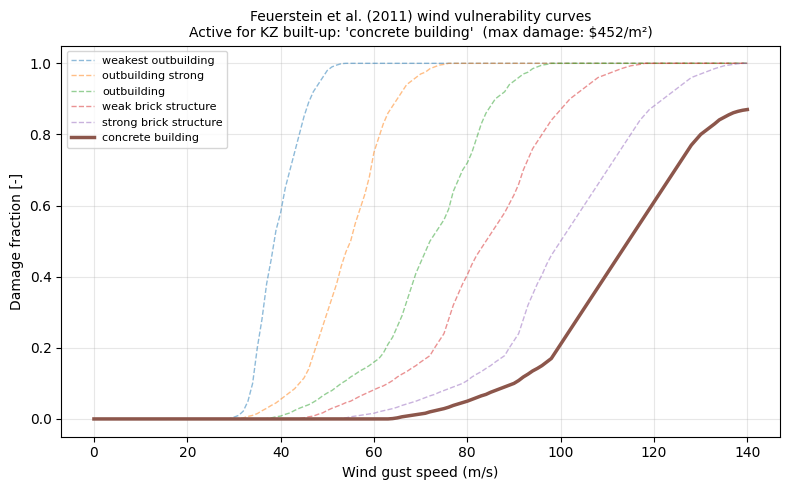

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
for col in curves_feuerstein.columns:
    lw   = 2.5 if col == BUILT_UP_CURVE else 1.0
    ls   = '-'  if col == BUILT_UP_CURVE else '--'
    alpha= 1.0  if col == BUILT_UP_CURVE else 0.5
    ax.plot(curves_feuerstein.index, curves_feuerstein[col],
            label=col, linewidth=lw, linestyle=ls, alpha=alpha)
ax.set_xlabel('Wind gust speed (m/s)')
ax.set_ylabel('Damage fraction [-]')
ax.set_title(
    f'Feuerstein et al. (2011) wind vulnerability curves\n'
    f'Active for KZ built-up: {BUILT_UP_CURVE!r}  '
    f'(max damage: ${MAXDAM_BUILT_UP_USD:.0f}/m²)',
    fontsize=10
)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(plot_dir / f'VulnerabilityCurves_{region_name}.png', dpi=150)
plt.show()

## 4 — Reproject footprint to match land cover grid

ERA5 resolution is ~0.25° (~28 km). We upsample to the ESA WC ~100m grid
using cubic interpolation (same approach as original CLIMAAX workflow).

**Limitation:** Upsampling 28 km data to 100m produces a smooth surface —
local sub-pixel wind variability is not captured. Use this output to
identify broad high-damage zones, not individual building-level risk.

Matched footprint shape : (8283, 10017)
Saved: windstorm_matched_buran_nov2023_PavlodarRegion.tif


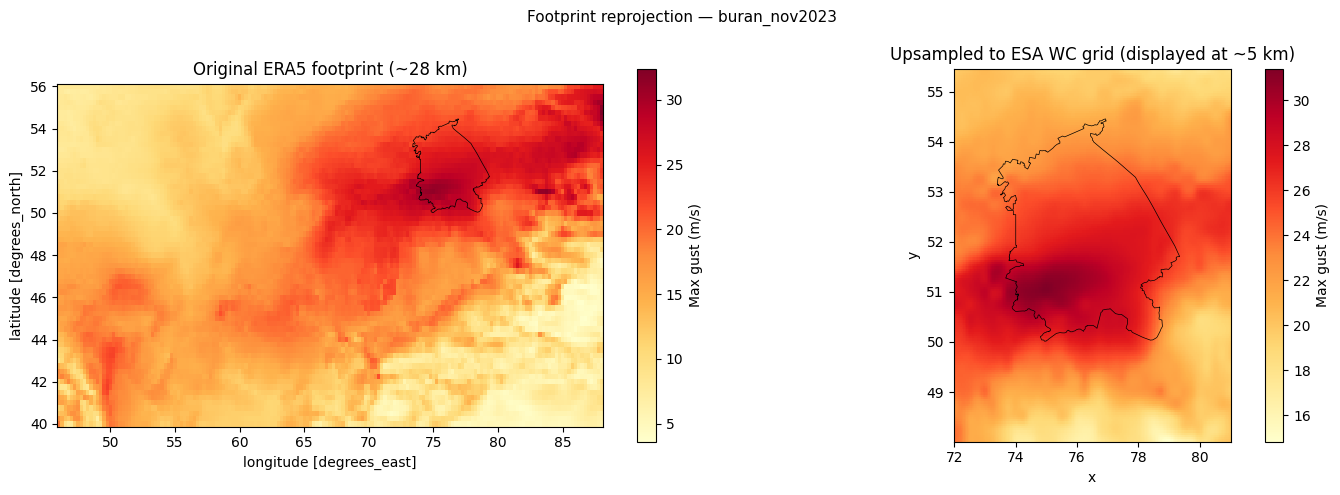

In [ ]:
windstorm_matched = windstorm_region.rio.reproject_match(
    esa_wc_local, resampling=Resampling.cubic
)
windstorm_matched = windstorm_matched.assign_coords({
    'x': esa_wc_local.x,
    'y': esa_wc_local.y,
})
windstorm_matched = windstorm_matched.where(windstorm_matched > 0)

windstorm_matched_path = data_dir / f'windstorm_matched_{storm_name}_{region_name}.tif'
windstorm_matched.rio.to_raster(str(windstorm_matched_path))
print(f'Matched footprint shape : {windstorm_matched.shape}')
print(f'Saved: {windstorm_matched_path.name}')

PLOT_STEP = 50   
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
windstorm_region.plot(ax=ax1, cmap='YlOrRd',
                      cbar_kwargs={'label': 'Max gust (m/s)'})
ax1.set_title('Original ERA5 footprint (~28 km)')
windstorm_matched.isel(x=slice(None, None, PLOT_STEP),
                       y=slice(None, None, PLOT_STEP)).plot(
    ax=ax2, cmap='YlOrRd', cbar_kwargs={'label': 'Max gust (m/s)'}
)
ax2.set_title('Upsampled to ESA WC grid (displayed at ~5 km)')
for ax in (ax1, ax2):
    region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
plt.suptitle(f'Footprint reprojection — {storm_name}', fontsize=11)
plt.tight_layout()
fig.savefig(plot_dir / f'FootprintMatch_{storm_name}_{region_name}.png', dpi=150)
plt.show()

## 5 — Damage calculation

**Substitution:** DamageScanner → direct numpy raster calculation.
For each pixel: damage_fraction × max_damage_USD_per_m² (= damage in USD/m²).
Only built-up pixels (ESA WC class 50) receive wind damage.

Note: pixel area is approximated as 100m × 100m = 10,000 m².
At 45°N true east-west pixel width is ~70m, so absolute totals are slightly
overestimated (~30%). This is a known limitation shared with the flood workflow.

In [ ]:
with rasterio.open(windstorm_matched_path) as src:
    wind_arr = src.read(1).astype(float)
    wind_arr[wind_arr <= 0] = np.nan

with rasterio.open(landcover_path) as src:
    lc_arr   = src.read(1).astype(float)
    lc_meta  = src.meta.copy()

wind_speeds = curves_feuerstein.index.astype(float).values
damage_frac = curves_feuerstein[BUILT_UP_CURVE].values

damage_map = np.zeros_like(wind_arr, dtype=np.float64)

mask_built = (lc_arr == 50) & ~np.isnan(wind_arr)
if mask_built.any():
    frac = np.interp(wind_arr[mask_built], wind_speeds, damage_frac)
    damage_map[mask_built] = frac * MAXDAM_BUILT_UP_USD

dmg_path = results_dir / f'wind_{storm_name}_{region_name}_damagemap.tif'
meta = lc_meta.copy()
meta.update(dtype='float64', count=1, nodata=0)
with rasterio.open(dmg_path, 'w', **meta) as dst:
    dst.write(damage_map, 1)
print(f'Saved damage map: {dmg_path.name}')

pixel_area_m2 = 100 * 100
total_damage_usd = damage_map.sum() * pixel_area_m2
n_pixels_built   = int(mask_built.sum())
n_pixels_damaged = int((damage_map > 0).sum())
print(f'\n--- Damage summary ---')
print(f'Built-up pixels in region  : {n_pixels_built:,}')
print(f'Built-up pixels with damage: {n_pixels_damaged:,}')
print(f'Total estimated damage     : ${total_damage_usd/1e6:.2f}M USD')
print(f'  (Note: pixel area ≈100m×100m; ~30% overestimate at 45°N)')

Saved damage map: wind_buran_nov2023_PavlodarRegion_damagemap.tif

--- Damage summary ---
Built-up pixels in region  : 245,223
Built-up pixels with damage: 77,554
Total estimated damage     : $75.57M USD
  (Note: pixel area ≈100m×100m; ~30% overestimate at 45°N)


## 6 — Relative damage map

Relative damage = damage fraction at each pixel (0–1), independent of
asset value. Shows which locations are structurally most affected.

In [44]:
rel_damage_map = np.zeros_like(wind_arr, dtype=np.float64)
if mask_built.any():
    rel_damage_map[mask_built] = np.interp(
        wind_arr[mask_built], wind_speeds, damage_frac
    )

rel_dmg_path = results_dir / f'wind_{storm_name}_{region_name}_reldamagemap.tif'
with rasterio.open(rel_dmg_path, 'w', **meta) as dst:
    dst.write(rel_damage_map, 1)
print(f'Saved relative damage map: {rel_dmg_path.name}')

Saved relative damage map: wind_buran_nov2023_PavlodarRegion_reldamagemap.tif


## 7 — Plot results

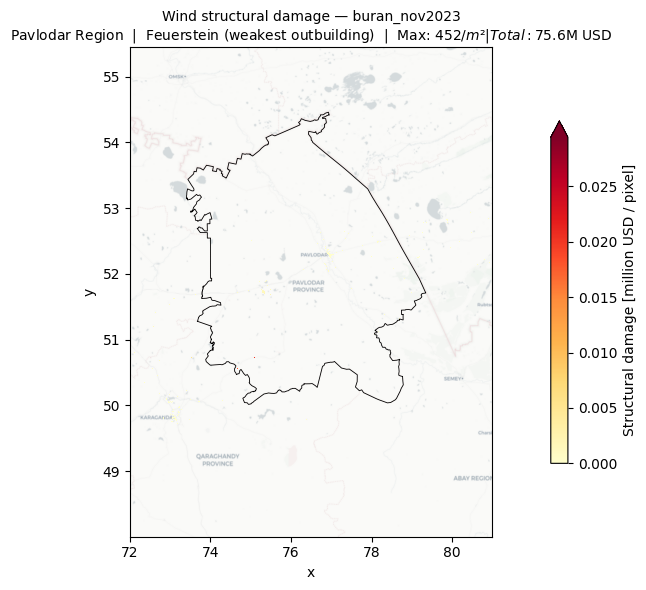

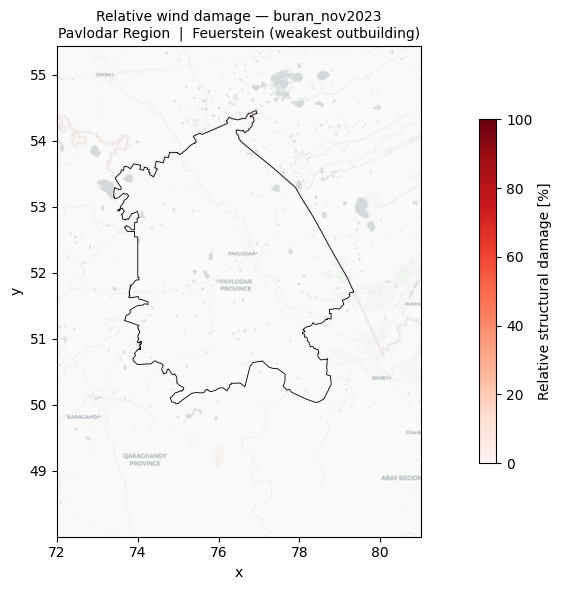

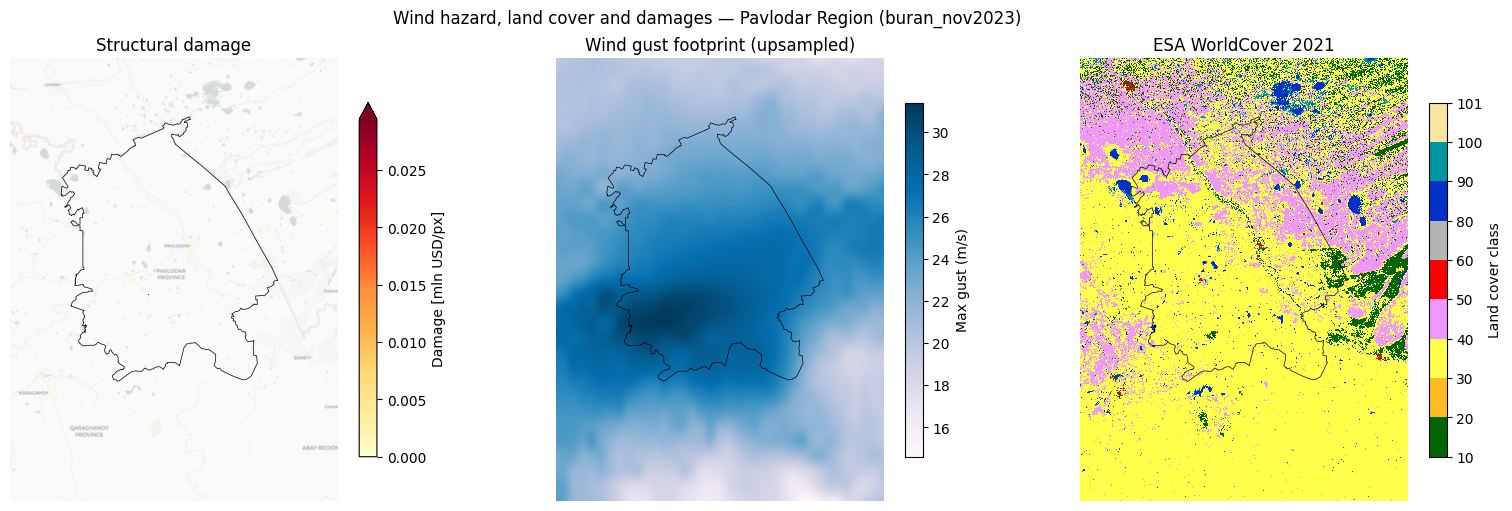

In [ ]:
dmg_rxr = rxr.open_rasterio(dmg_path).squeeze()
dmg_rxr = (dmg_rxr.where(dmg_rxr > 0)) * pixel_area_m2 / 1e6   # → million USD per pixel

rel_rxr = rxr.open_rasterio(rel_dmg_path).squeeze()
rel_rxr = rel_rxr.where(rel_rxr > 0) * 100   # → percent

fig, ax = plt.subplots(figsize=(12, 6))
vmax_dmg = float(np.nanpercentile(dmg_rxr.values[dmg_rxr.values > 0], 99)) \
           if (dmg_rxr.values > 0).any() else 0.001
dmg_rxr.isel(x=slice(None, None, 3), y=slice(None, None, 3)).plot(
    ax=ax, cmap='YlOrRd', vmin=0, vmax=vmax_dmg,
    cbar_kwargs={'label': 'Structural damage [million USD / pixel]', 'shrink': 0.7}
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)
ctx.add_basemap(ax=ax, crs='EPSG:4326',
                source=ctx.providers.CartoDB.Positron, attribution=False)
ax.set_title(
    f'Wind structural damage — {storm_name}\n'
    f'{analysis_label}  |  Feuerstein ({BUILT_UP_CURVE})  |  '
    f'Max: ${MAXDAM_BUILT_UP_USD:.0f}/m²  |  Total: ${total_damage_usd/1e6:.1f}M USD',
    fontsize=10
)
plt.tight_layout()
fig.savefig(plot_dir / f'DamageMap_{storm_name}_{region_name}.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
rel_rxr.isel(x=slice(None, None, 3), y=slice(None, None, 3)).plot(
    ax=ax, cmap='Reds', vmin=0, vmax=100,
    cbar_kwargs={'label': 'Relative structural damage [%]', 'shrink': 0.7}
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)
ctx.add_basemap(ax=ax, crs='EPSG:4326',
                source=ctx.providers.CartoDB.Positron, attribution=False)
ax.set_title(
    f'Relative wind damage — {storm_name}\n'
    f'{analysis_label}  |  Feuerstein ({BUILT_UP_CURVE})',
    fontsize=10
)
plt.tight_layout()
fig.savefig(plot_dir / f'RelDamageMap_{storm_name}_{region_name}.png', dpi=150)
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True,
                         sharex=True, sharey=True)

dmg_rxr.isel(x=slice(None, None, 3), y=slice(None, None, 3)).plot(
    ax=axs[0], cmap='YlOrRd', vmin=0, vmax=vmax_dmg,
    cbar_kwargs={'label': 'Damage [mln USD/px]', 'shrink': 0.8}
)
axs[0].set_title('Structural damage')

windstorm_matched.isel(x=slice(None, None, 3), y=slice(None, None, 3)).plot(
    ax=axs[1], cmap='PuBu',
    cbar_kwargs={'label': 'Max gust (m/s)', 'shrink': 0.8}
)
axs[1].set_title('Wind gust footprint (upsampled)')

esa_wc_local.isel(x=slice(None, None, 3), y=slice(None, None, 3)).plot(
    ax=axs[2], cmap=cmap_lc, norm=norm_lc,
    cbar_kwargs={'label': 'Land cover class', 'shrink': 0.8}
)
axs[2].set_title('ESA WorldCover 2021')

for ax in axs:
    region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
    ctx.add_basemap(ax, crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution=False)
    ax.set_axis_off()

fig.suptitle(
    f'Wind hazard, land cover and damages — {analysis_label} ({storm_name})',
    fontsize=12
)
fig.savefig(plot_dir / f'DetailMap_{storm_name}_{region_name}.png', dpi=150)
plt.show()

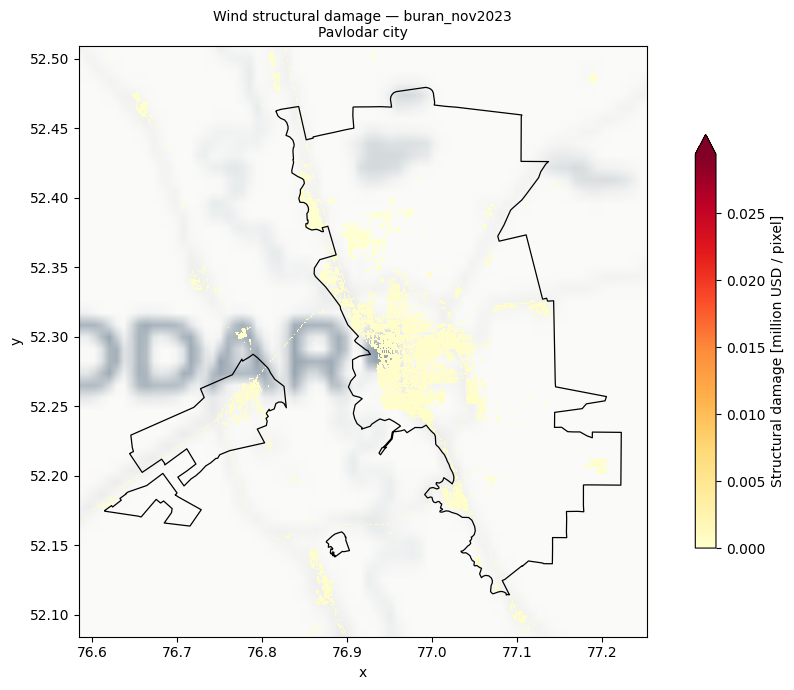

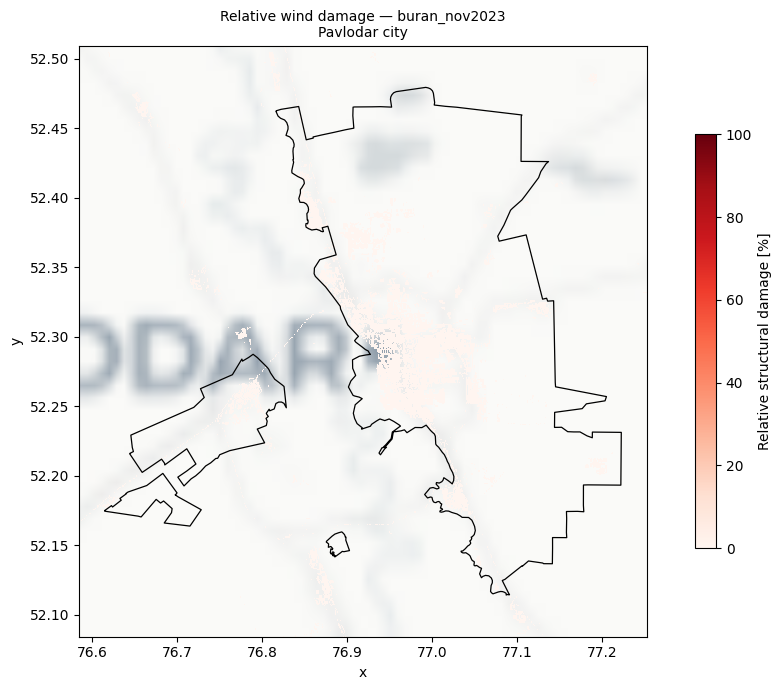

In [ ]:
if oblast_filter == 'Pavlodar Region':
    pavlodar_city = kaz[(kaz['oblast_en'] == 'Pavlodar Region') & (kaz['name_en'] == 'Pavlodar')]
    buf = 0.03
    city_xlim = (pavlodar_city.total_bounds[0] - buf, pavlodar_city.total_bounds[2] + buf)
    city_ylim = (pavlodar_city.total_bounds[1] - buf, pavlodar_city.total_bounds[3] + buf)

    fig, ax = plt.subplots(figsize=(10, 7))
    dmg_rxr.plot(ax=ax, cmap='YlOrRd', vmin=0, vmax=vmax_dmg,
                cbar_kwargs={'label': 'Structural damage [million USD / pixel]', 'shrink': 0.7})
    pavlodar_city.boundary.plot(ax=ax, color='black', linewidth=0.9)
    ctx.add_basemap(ax=ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution=False)
    ax.set_xlim(city_xlim)
    ax.set_ylim(city_ylim)
    ax.set_title(f'Wind structural damage — {storm_name}\nPavlodar city', fontsize=10)
    plt.tight_layout()
    fig.savefig(plot_dir / f'DamageMap_{storm_name}_PavlodarCity.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 7))
    rel_rxr.plot(ax=ax, cmap='Reds', vmin=0, vmax=100,
                cbar_kwargs={'label': 'Relative structural damage [%]', 'shrink': 0.7})
    pavlodar_city.boundary.plot(ax=ax, color='black', linewidth=0.9)
    ctx.add_basemap(ax=ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution=False)
    ax.set_xlim(city_xlim)
    ax.set_ylim(city_ylim)
    ax.set_title(f'Relative wind damage — {storm_name}\nPavlodar city', fontsize=10)
    plt.tight_layout()
    fig.savefig(plot_dir / f'RelDamageMap_{storm_name}_PavlodarCity.png', dpi=150)
    plt.show()

## Conclusions

This risk workflow estimated structural wind damage for Kazakhstan by combining:

- **Hazard:** ERA5 storm footprint — buran_nov2023 (18–19 November 2023),
max 10m wind gust ~31 m/s over Pavlodar Region, upsampled to ~100m
- **Exposure:** ESA WorldCover 2021 — only class 50 (built-up) carries structural
  damage value; other land-cover classes are not modelled for wind damage
- **Vulnerability:** Feuerstein et al. (2011) curves — 'weakest outbuilding' applied to all built-up
pixels; selected because observed gusts (max ~31 m/s) fall below the onset
threshold of stronger curves; max damage from Huizinga 2017 Central Asia
values ($452/m²)

**Key limitations:**
- ERA5 at 0.25° (~28 km) underestimates peak gusts, particularly for intense
buran events. Pavlodar Region is flat steppe so ERA5 performance is better
here than in mountainous areas, but damage totals remain likely underestimates.
- Feuerstein curves were calibrated against Central European building stock.
  No published wind vulnerability curves exist for post-Soviet construction.
- All built-up pixels use the same single curve — no distinction between
  residential, commercial, or industrial assets within class 50.
- Pixel area approximated as 100m × 100m; ~30% overestimate at 45°N latitude.

- 'weakest outbuilding' curve was calibrated for Central European lightweight
  structures. Pavlodar's building stock includes both Soviet-era panel construction
  (more robust) and rural outbuildings (more vulnerable). The curve represents
  the most exposed asset class only.

## References

- Feuerstein et al. (2011). doi:10.1016/j.atmosres.2010.12.026
- Huizinga et al. (2017). JRC105688. doi:10.2760/16510
- Koks & Haer (2020). doi:10.1038/s41598-020-63580-w